# 01 · EDA — distribución de los retornos a lo largo del día

Este notebook responde a la parte del enunciado que pide "estudiar la
distribución a lo largo del día" de los datos de 5 minutos, y justifica
**por qué** merece la pena rellenar con sintéticos la volatilidad
intradía en los 28 años sin barras de 5 min reales:

1. El perfil de volatilidad/volumen a lo largo de la sesión tiene una
   forma muy característica (forma de "U": alta al abrir, baja a
   mediodía, alta al cerrar) — igual en un banco grande (JPM) que en uno
   pequeño (GBCI), aunque con distinta magnitud.
2. La volatilidad realizada intradía (`realized_vol`, calculada con las
   barras de 5 min) **no es redundante** con el retorno diario
   close-to-close que ya tenemos 30 años reales: están correlacionadas
   (~0.45) pero lejos de ser la misma variable — por eso es una feature
   que aporta información nueva al predictor, y por eso el backfill
   condicional (notebook 03) tiene sentido: hay variabilidad genuina que
   modelar, no una relación determinista.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_norgate as dn, features as feat, plotting as pl

## 1. Datos: dos bancos de tamaño muy distinto

JPM (money-center, muy líquido) vs. GBCI (banco regional pequeño), toda
la historia real de 5 minutos disponible en caché (~5-6 años; el
pipeline final solo usa los últimos 2, pero para el EDA usamos todo lo
que hay para tener una muestra más rica).

In [2]:
tickers_demo = ["JPM", "GBCI"]
bars = {tk: pd.read_parquet(config.RAW_DIR / "eodhd_5m" / f"{tk}.parquet") for tk in tickers_demo}
for tk, b in bars.items():
    print(f"{tk}: {len(b):,} barras de 5 min, {b.index.min()} -> {b.index.max()}")

JPM: 114,928 barras de 5 min, 2020-11-02 14:30:00+00:00 -> 2026-08-28 20:00:00+00:00
GBCI: 114,924 barras de 5 min, 2020-11-02 14:30:00+00:00 -> 2026-08-28 20:00:00+00:00


## 2. Perfil intradía: forma de "U" de la volatilidad

Media de `|retorno de 5 min|` por franja horaria (hora local de mercado,
ET) a lo largo de toda la muestra: alta justo tras la apertura (9:30 ET),
mínima a mediodía, y repunta hacia el cierre (16:00 ET).

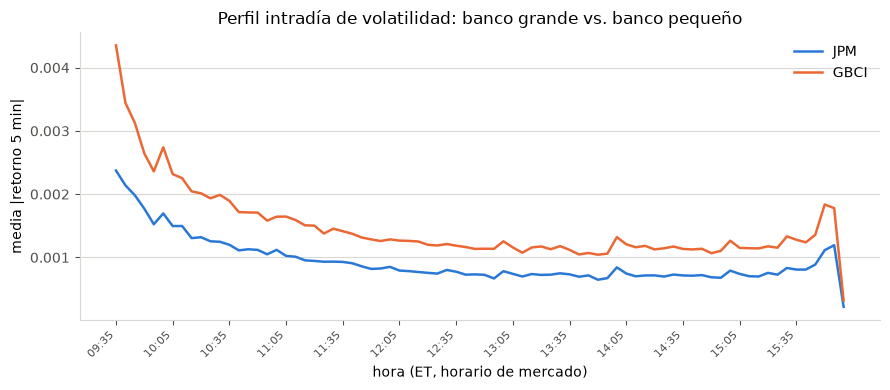

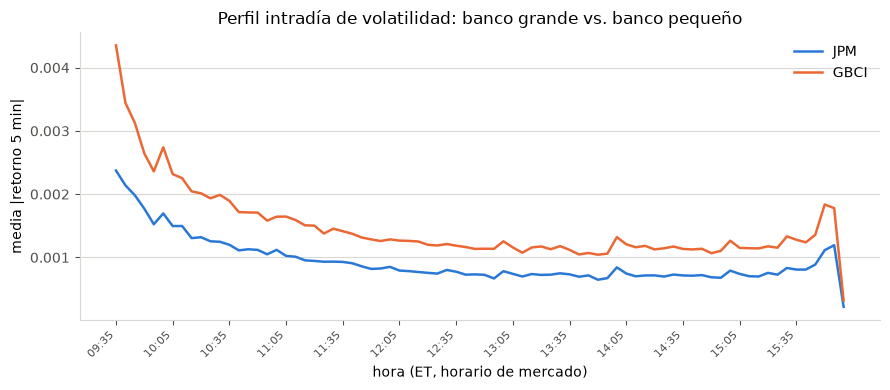

In [3]:
profiles = {tk: feat.intraday_time_of_day_profile(b) for tk, b in bars.items()}

fig, ax = plt.subplots(figsize=(9, 4))
for tk in tickers_demo:
    prof = profiles[tk]
    x = np.arange(len(prof))
    ax.plot(x, prof["mean_abs_ret"].values, label=tk, linewidth=1.8,
            color=pl.color_for("real" if tk == "JPM" else "synthetic"))
step = max(len(profiles["JPM"]) // 12, 1)
ax.set_xticks(x[::step])
ax.set_xticklabels(profiles["JPM"].index[::step], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("hora (ET, horario de mercado)")
ax.set_ylabel("media |retorno 5 min|")
ax.set_title("Perfil intradía de volatilidad: banco grande vs. banco pequeño")
ax.legend(frameon=False)
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "01_perfil_intradia_volatilidad")
fig

Mismo patrón con el volumen: pico al abrir, valle a mediodía, repunte al
cerrar (más marcado incluso que en volatilidad — muchos gestores ejecutan
en la subasta de cierre).

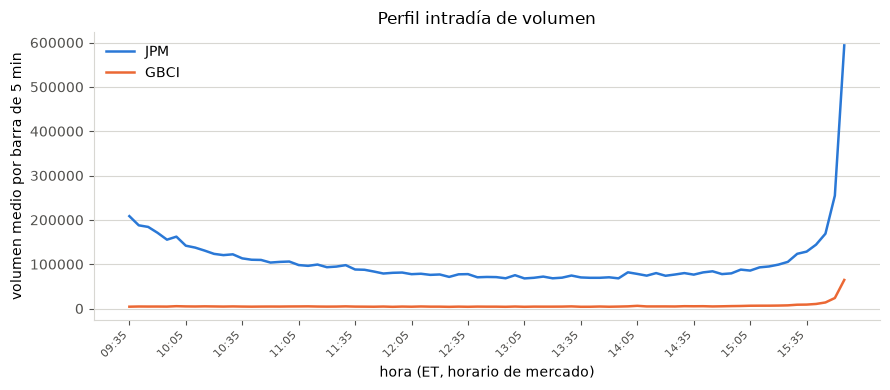

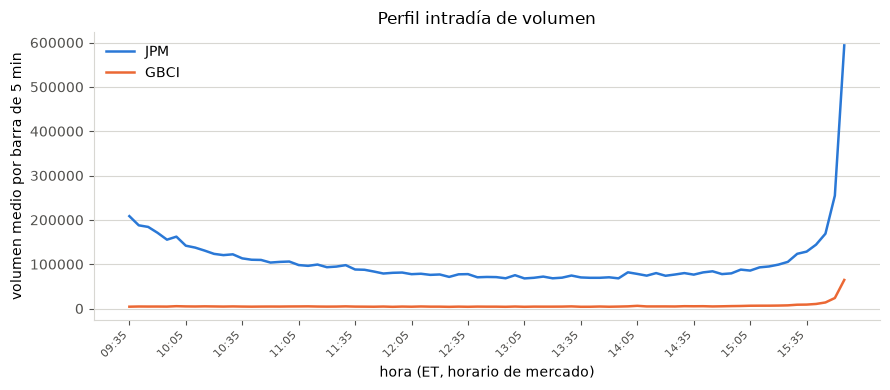

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for tk in tickers_demo:
    prof = profiles[tk]
    x = np.arange(len(prof))
    ax.plot(x, prof["mean_volume"].values, label=tk, linewidth=1.8,
            color=pl.color_for("real" if tk == "JPM" else "synthetic"))
ax.set_xticks(x[::step])
ax.set_xticklabels(profiles["JPM"].index[::step], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("hora (ET, horario de mercado)")
ax.set_ylabel("volumen medio por barra de 5 min")
ax.set_title("Perfil intradía de volumen")
ax.legend(frameon=False)
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "01_perfil_intradia_volumen")
fig

## 3. Features intradía diarias: distribución de la volatilidad realizada

`realized_vol = sqrt(sum(retornos de 5 min ^ 2))` por sesión — el
estimador de volatilidad de referencia en microestructura, el que
necesitamos reconstruir sintéticamente para los 28 años sin 5 min reales.

In [5]:
daily_feats = {tk: feat.daily_intraday_features(b) for tk, b in bars.items()}
for tk, f in daily_feats.items():
    print(f"--- {tk} ---")
    print(f["realized_vol"].describe().round(4))

--- JPM ---
count    1462.0000
mean        0.0113
std         0.0047
min         0.0037
25%         0.0084
50%         0.0103
75%         0.0130
max         0.0810
Name: realized_vol, dtype: float64
--- GBCI ---
count    1462.0000
mean        0.0176
std         0.0065
min         0.0071
25%         0.0135
50%         0.0164
75%         0.0202
max         0.0846
Name: realized_vol, dtype: float64


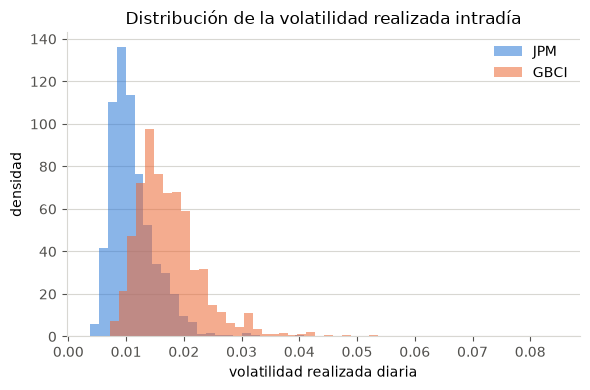

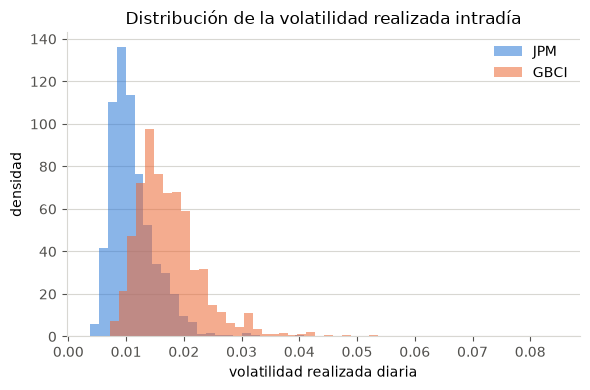

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
for tk in tickers_demo:
    ax.hist(
        daily_feats[tk]["realized_vol"], bins=50, density=True, alpha=0.55,
        label=tk, color=pl.color_for("real" if tk == "JPM" else "synthetic"),
    )
ax.set_xlabel("volatilidad realizada diaria")
ax.set_ylabel("densidad")
ax.set_title("Distribución de la volatilidad realizada intradía")
ax.legend(frameon=False)
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "01_distribucion_realized_vol")
fig

## 4. ¿Aporta algo la volatilidad intradía que no tengamos ya con el
   retorno diario close-to-close?

Si `realized_vol` estuviera perfectamente determinada por
`|retorno diario|`, no tendría sentido molestarse en reconstruirla: el
predictor ya tiene el retorno diario real los 30 años. La correlación es
alta pero está lejos de 1 — hay información genuina en la trayectoria
intradía que el cierre diario no captura.

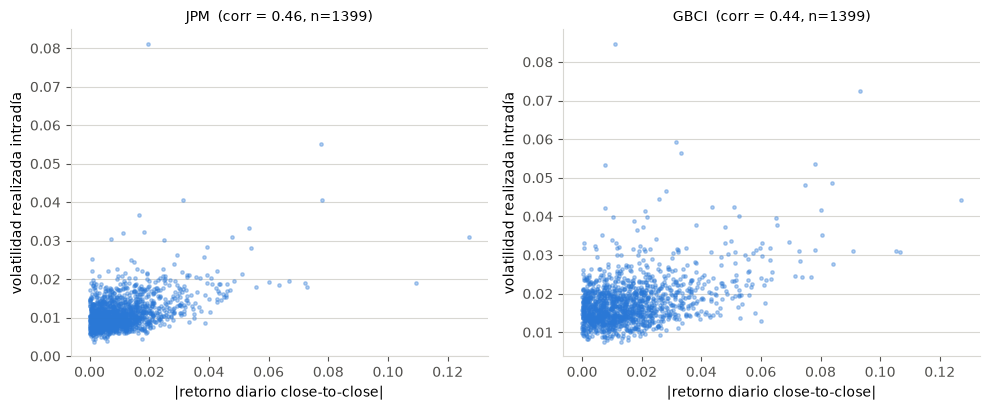

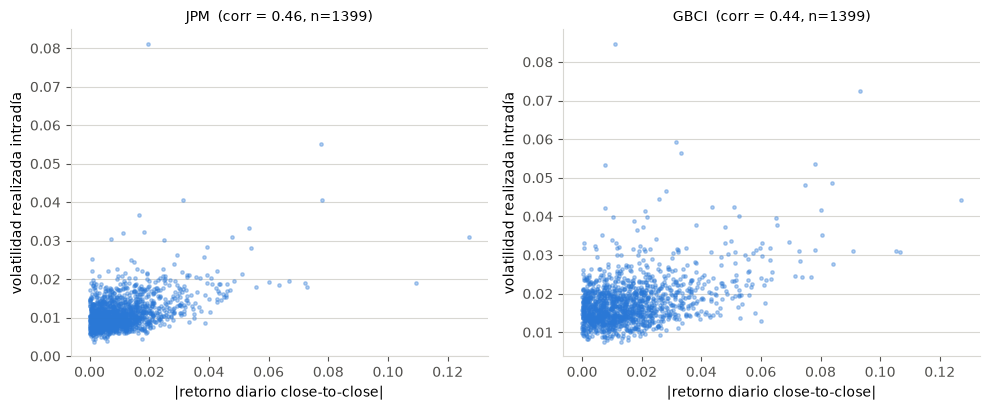

In [7]:
prices = dn.load_daily_prices(tickers_demo)
returns_demo = dn.compute_log_returns(prices)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
corr_table = {}
for ax, tk in zip(axes, tickers_demo):
    idx = returns_demo.index.intersection(daily_feats[tk].index)
    r_abs = returns_demo.loc[idx, tk].abs()
    rv = daily_feats[tk].loc[idx, "realized_vol"]
    corr = np.corrcoef(r_abs, rv)[0, 1]
    corr_table[tk] = corr
    ax.scatter(r_abs, rv, s=6, alpha=0.35, color=pl.PALETTE["real"])
    ax.set_xlabel("|retorno diario close-to-close|")
    ax.set_ylabel("volatilidad realizada intradía")
    ax.set_title(f"{tk}  (corr = {corr:.2f}, n={len(idx)})", fontsize=10)
    pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "01_relacion_retorno_vs_realized_vol")
fig

In [8]:
pd.Series(corr_table, name="corr(|retorno diario|, realized_vol)").to_csv(
    config.TABLES_DIR / "01_correlacion_retorno_rv.csv"
)
print(
    "Correlacion moderada (no redundancia perfecta): la volatilidad intradia "
    "aporta informacion que el retorno diario, por si solo, no tiene — de ahi "
    "que merezca la pena reconstruirla sinteticamente para los 28 anios sin "
    "5 minutos reales (notebook 03)."
)

Correlacion moderada (no redundancia perfecta): la volatilidad intradia aporta informacion que el retorno diario, por si solo, no tiene — de ahi que merezca la pena reconstruirla sinteticamente para los 28 anios sin 5 minutos reales (notebook 03).
